# Diff-SSL TVC-LSTM — local eval / monitor (conditioned direct output)

Scores the **conditioned, multi-setting** TVC-LSTM trained in
[`train_lstm_diffssl_tvc.ipynb`](train_lstm_diffssl_tvc.ipynb) using the
**same audio-metric table** (`src.losses.compute_all_losses`) as the SOTA /
GR evals, and the **exact validation split** stored in each run's
`split_manifest.json` (`splits.build_split_manifest`, seed 42 — val = 1 song ×
all 10 settings).

Unlike the direct-output SOTA LSTM, this model is **conditioned** on the four
static knobs (`threshold, attack, release, ratio`, normalised to `[0, 1]` via
`splits.normalize_setting_params`) and processes audio with a **stateful**
sample-rate LSTM + `TVFiLMCond`. Whole-song prediction therefore keeps LSTM
state continuous across chunk boundaries (reset once per song), feeding the
per-setting control vector throughout.

Includes a **conditioning sweep** (one song through all 10 settings) matching
[`eval_lstm_tfilm_gr.ipynb`](../05_conditioning/eval_lstm_tfilm_gr.ipynb).

For visual comparison with the GR predictors, the preview cells **derive a
gain-reduction curve** from the predicted/target audio (1024-sample moving RMS →
dB) and plots target-vs-predicted GR in the same 3-panel layout.

The validation CSV is written as `eval_audio_metrics_validation.csv` inside the
run folder — same schema as the SOTA / GR runs, plus a **per-setting breakdown**
so conditioning quality can be inspected across the threshold sweep.

Runs on the **laptop** (reads Drive-synced run folders). No Colab needed.

> Requirements: `uv sync` at repo root.

In [1]:
# ── 0. Imports and defaults ──────────────────────────────
#
# nablafx pulls in `rational` (DDSP) and `frechet_audio_distance` (system) at
# import time — stub both so we never drag in tensorflow/encodec on the laptop,
# exactly as the training notebook (cell 0) does.

import sys, types

rational = types.ModuleType("rational")
rational.torch = types.ModuleType("rational.torch")
rational.torch.Rational = type("Rational", (), {})
sys.modules["rational"], sys.modules["rational.torch"] = rational, rational.torch

fad = types.ModuleType("frechet_audio_distance")
fad.FrechetAudioDistance = type("FrechetAudioDistance", (), {})
sys.modules["frechet_audio_distance"] = fad

import os, glob, json, gc, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import lightning as pl

warnings.filterwarnings("ignore", category=UserWarning)

# This notebook lives in 02b_sota_training/ alongside dataset.py / splits.py /
# model.py / system.py; the shared eval helpers live next to the GR eval.
SOTA_DIR = Path.cwd() if Path.cwd().name == "02b_sota_training" else Path.cwd() / "02b_sota_training"
REPO_ROOT = SOTA_DIR.parent
GR_DIR = REPO_ROOT / "03_initial_GR_pred"
for p in (str(SOTA_DIR), str(GR_DIR)):
    if p not in sys.path:
        sys.path.insert(0, p)

from src.losses import compute_all_losses
# Same GR DSP helpers the GR predictor uses, so derived GR curves are directly
# comparable (1024-sample windowed RMS, dB gain reduction).
from src.dsp_torch import RMS_WINDOW, GR_DB_MIN, GR_DB_MAX, gain_reduction_db
from eval_helpers import (
    _checkpoint_sort_key, latest_best_checkpoint, list_runs, plot_loss_curves,
    _read_dry_wet_segment, _pair_num_frames, _weighted_average_metric_rows,
    _find_hparams_json,
)
# diffssl dataset / split / model / system (same modules the training notebook uses)
from dataset import discover_diffssl_wet_pairs
from splits import SplitManifest, filter_pairs_by_keys, pair_key
from model import build_diffssl_tvc_lstm
from system import DiffSSLTVCLSTMSystem

DATA_ROOT = "/Volumes/Saola's Drive/AllCode/thesis/data/Diff-SSL-G-Comp"
RUNS_DIR  = "/Volumes/Saola's Drive/AllCode/thesis/data/diffssl_tvc_runs"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"torch {torch.__version__}  |  device: {DEVICE}  |  RMS window: {RMS_WINDOW}")

/Volumes/Saola's Drive/AllCode/thesis/Virtual-Analogue-Compressor-Modelling/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch 2.10.0  |  device: cpu  |  RMS window: 1024


In [2]:
# ── 1. List available Diff-SSL TVC-LSTM runs ───────────────────

assert RUNS_DIR and os.path.isdir(RUNS_DIR), f"RUNS_DIR not found: {RUNS_DIR}"

runs_df = list_runs(RUNS_DIR)
assert not runs_df.empty, "No runs found yet."

available_df = runs_df[runs_df["type"] == "nablafx_diffssl_LSTM_tvcond"].copy()
assert not available_df.empty, "No Diff-SSL TVC-LSTM runs found."

cols = ["run", "type", "epoch", "best_val", "n_ckpts", "eval_ckpt", "modified"]
print(f"Available Diff-SSL TVC-LSTM runs: {len(available_df)}")
display(available_df[cols])

Available Diff-SSL TVC-LSTM runs: 3


,run,type,epoch,best_val,n_ckpts,eval_ckpt,modified
0,diffssl_tvc_20260624_150623_diffssl_lstm32_tvc...,nablafx_diffssl_LSTM_tvcond,6,0.833025,4,best-006-26656.ckpt,2026-06-24 15:08:44.543672323
1,diffssl_tvc_20260624_152458_diffssl_lstm32_tvc...,nablafx_diffssl_LSTM_tvcond,1,0.062436,3,best-001-24360.ckpt,2026-06-24 15:28:23.319058180
2,diffssl_tvc_20260624_153343_diffssl_lstm32_tvc...,nablafx_diffssl_LSTM_tvcond,74,0.037413,4,best-073-901320.ckpt,2026-06-24 16:16:32.855252743


In [3]:
# ── 2. Select run and checkpoint ─────────────────────────

# Defaults to the most recent run; set explicitly to pin one.
SELECTED_RUN_NAME = str(available_df.iloc[-1]["run"])

matches = available_df[available_df["run"] == SELECTED_RUN_NAME]
assert len(matches) == 1, f"Run not found: {SELECTED_RUN_NAME}"
selected_run = matches.iloc[0]

RUN_NAME = str(selected_run["run"])
RUN_DIR = os.path.join(RUNS_DIR, RUN_NAME)
HPARAMS_PATH = os.path.join(RUN_DIR, "hparams.json")
SPLIT_PATH = os.path.join(RUN_DIR, "split_manifest.json")
EVAL_CKPT_PATH = latest_best_checkpoint(RUN_DIR)

print(f"Selected run   : {RUN_NAME}")
print(f"Eval checkpoint: {os.path.basename(EVAL_CKPT_PATH)}")
if pd.notna(selected_run.get("best_val")):
    print(f"Best val loss  : {selected_run['best_val']:.6f}")

print("Checkpoints    :")
for c in sorted(glob.glob(os.path.join(RUN_DIR, "checkpoints", "*.ckpt")), key=_checkpoint_sort_key):
    marker = " <-- eval" if os.path.abspath(c) == os.path.abspath(EVAL_CKPT_PATH) else ""
    print(f"  {os.path.basename(c):<36}  {os.path.getsize(c)/1e6:6.2f} MB{marker}")

SPLIT = SplitManifest.load(SPLIT_PATH)


def _pairs_from_keys(keys) -> list[tuple[str, str]]:
    return [tuple(k.split("::")) for k in sorted(keys)]


VAL_PAIR_KEYS = _pairs_from_keys(SPLIT.val_pair_keys)
TEST_PAIR_KEYS = _pairs_from_keys(SPLIT.test_pair_keys)
print(f"Val pairs      : {len(VAL_PAIR_KEYS)}  ({SPLIT.val_songs} x all settings)")
print(f"Test pairs     : {len(TEST_PAIR_KEYS)}  ({SPLIT.test_songs} x {SPLIT.test_settings})")


Selected run   : diffssl_tvc_20260624_153343_diffssl_lstm32_tvc_multisetting
Eval checkpoint: best-073-901320.ckpt
Best val loss  : 0.037413
Checkpoints    :
  last.ckpt                               0.11 MB
  best-044-548100.ckpt                    0.11 MB
  best-066-816060.ckpt                    0.11 MB
  best-073-901320.ckpt                    0.11 MB <-- eval
Val pairs      : 10  (['Ecstasy'] x all settings)
Test pairs     : 4  (['Air', 'AncoraQui'] x ['threshold_-12_attack_10_release_0.4_ratio_10', 'threshold_-12_attack_1_release_0.1_ratio_2'])


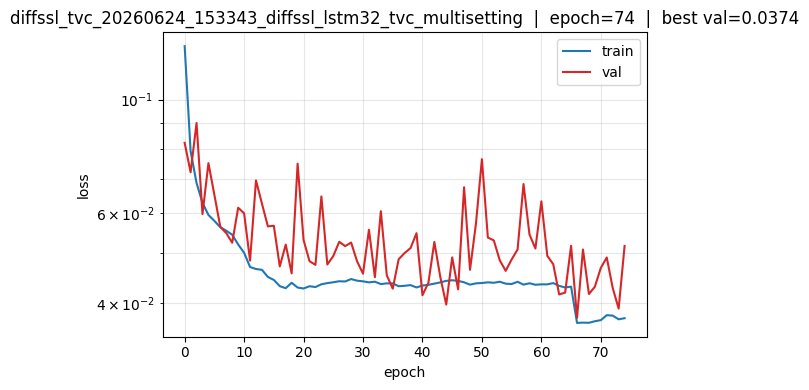

In [4]:
# ── 3. Loss curves ────────────────────────────────

_ = plot_loss_curves(RUN_DIR)

In [5]:
# ── 4. Model definition & checkpoint loader ─────────────────
# Rebuilds the BlackBoxModel(LSTM tvcond) from the run's hparams and loads the
# DiffSSLTVCLSTMSystem weights — must match train_lstm_diffssl_tvc.ipynb.


def load_system_from_ckpt(ckpt_path: str, hparams_path: str | None = None):
    if hparams_path is None:
        hparams_path = _find_hparams_json(ckpt_path)
    assert hparams_path and os.path.isfile(hparams_path), f"hparams.json not found near {ckpt_path}"
    with open(hparams_path) as f:
        hp = json.load(f)

    m = hp["model"]
    model = build_diffssl_tvc_lstm(
        hidden_size=int(m["hidden_size"]),
        num_layers=int(m["num_layers"]),
        num_controls=int(m["num_controls"]),
        cond_block_size=int(m["cond_block_size"]),
        cond_num_layers=int(m["cond_num_layers"]),
    )
    system = DiffSSLTVCLSTMSystem.load_from_checkpoint(
        ckpt_path, model=model, map_location=DEVICE)
    system.to(DEVICE).eval()
    return system, hp


# Block size used by TVFiLMCond pooling; keep eval chunks block-aligned so the
# conditioning state advances identically across whole-song chunk boundaries.
def _cond_block_size(hp: dict) -> int:
    return int(hp["model"].get("cond_block_size", 128))


print("Diff-SSL TVC-LSTM model + loader registered.")

Diff-SSL TVC-LSTM model + loader registered.


In [6]:
# ── 5. Validation pairs (exact split manifest) + stateful prediction ──
#
# The validation set is the per-run split_manifest.json (val song × every
# setting). Each pair carries its normalised 4-knob control vector, fed to the
# conditioned model throughout the song.
#
# Because the LSTM + TVFiLMCond are STATEFUL, a whole song is predicted with a
# single `reset_states()` at the head, then contiguous block-aligned chunks that
# carry hidden state across boundaries (constant memory, exact continuity).


def validation_pairs(split_path: str, data_root: str = DATA_ROOT) -> list[dict]:
    split = SplitManifest.load(split_path)
    all_pairs = discover_diffssl_wet_pairs(data_root)
    val = filter_pairs_by_keys(all_pairs, set(split.val_pair_keys))
    return sorted(val, key=lambda p: (p["setting"], p["song"]))


def test_pairs(split_path: str, data_root: str = DATA_ROOT) -> list[dict]:
    split = SplitManifest.load(split_path)
    all_pairs = discover_diffssl_wet_pairs(data_root)
    test = filter_pairs_by_keys(all_pairs, set(split.test_pair_keys))
    return sorted(test, key=lambda p: (p["setting"], p["song"]))


@torch.no_grad()
def predict_wet_song(system, pair, sr, device, *, block_size=128,
                     chunk_sec=10.0, start=0, stop=None):
    """State-continuous whole-song (or [start, stop)) prediction.

    Returns (dry, wet, pred) each [1, T] on CPU, aligned to [start, stop).
    """
    dry_frames = _pair_num_frames(pair["dry"], pair["wet"], sr)
    stop = dry_frames if stop is None else min(stop, dry_frames)
    controls = torch.tensor(pair["params"], dtype=torch.float32).unsqueeze(0).to(device)

    # Block-aligned chunk length: no internal TVFiLMCond padding except the song
    # tail, so hidden state stays in lock-step with a single-pass forward.
    step = max(block_size, int(round(chunk_sec * sr)) // block_size * block_size)

    system.model.reset_states()
    drys, wets, preds = [], [], []
    cur = start
    while cur < stop:
        end = min(cur + step, stop)
        dry, wet = _read_dry_wet_segment(pair["dry"], pair["wet"], cur, end, sr)
        n = min(dry.shape[-1], wet.shape[-1])
        with torch.amp.autocast(device_type=device.type, enabled=device.type == "cuda"):
            out = system.model(dry[..., :n].unsqueeze(0).to(device), controls)
        out = out.squeeze(0).float().cpu()[..., :n]
        drys.append(dry[..., :n]); wets.append(wet[..., :n]); preds.append(out)
        cur = end
    return torch.cat(drys, -1), torch.cat(wets, -1), torch.cat(preds, -1)


print("Validation-pair + stateful prediction helpers registered.")

Validation-pair + stateful prediction helpers registered.


In [7]:
# ── 6. GR-curve preview & conditioning sweep (RMS-derived) ─────
#
# The model predicts wet output directly, so to compare against the GR
# predictors we DERIVE a gain-reduction curve post-hoc from the moving RMS of
# the audio (same 1024-sample helper):
#
#   GR(t) = 20*log10(rms(out)) - 20*log10(rms(dry))
#
# computed for the target wet AND the predicted wet.


def _pair_for(song: str, setting: str) -> dict:
    for p in discover_diffssl_wet_pairs(DATA_ROOT):
        if p["song"] == song and p["setting"] == setting:
            return p
    raise KeyError(f"No pair for song={song!r} setting={setting!r}")


EVAL_SYSTEM, HP = load_system_from_ckpt(EVAL_CKPT_PATH, HPARAMS_PATH)
_sr = int(HP["sample_rate"])
_block = _cond_block_size(HP)
_device = torch.device(DEVICE)


@torch.no_grad()
def predict_gr_curves(setting, song, start_sec=0.0, duration_sec=6.0,
                      system=None):
    """Predict a window and return aligned dry / GR target / GR pred arrays."""
    system = system or EVAL_SYSTEM
    pair = _pair_for(song, setting)
    start = int(round(start_sec * _sr))
    stop = start + int(round(duration_sec * _sr))
    dry, wet, pred = predict_wet_song(
        system, pair, _sr, _device,
        block_size=_block, chunk_sec=duration_sec,
        start=start, stop=stop,
    )
    gr_true = gain_reduction_db(dry.float(), wet.float(), RMS_WINDOW).squeeze().cpu().numpy()
    gr_pred = gain_reduction_db(dry.float(), pred.float(), RMS_WINDOW).squeeze().cpu().numpy()
    err = gr_pred - gr_true
    audio_losses = compute_all_losses(pred.unsqueeze(0), wet.unsqueeze(0))
    t_len = len(gr_true)
    return {
        "song": song, "setting": setting, "params": pair["params"],
        "sample_rate": _sr, "start_sec": start_sec, "duration_sec": t_len / _sr,
        "time": np.arange(t_len) / _sr,
        "dry": dry.squeeze().cpu().numpy(),
        "gr_true": gr_true, "gr_pred": gr_pred, "error": err,
        "mae_db": float(np.mean(np.abs(err))),
        "rmse_db": float(np.sqrt(np.mean(err ** 2))),
        "audio_esr": float(audio_losses["ESR"]),
    }


def visualize_prediction(setting=None, song=None, start_sec=30.0, duration_sec=6.0,
                         title=None):
    song = song or TEST_PAIR_KEYS[0][0]
    setting = setting or TEST_PAIR_KEYS[0][1]
    curves = predict_gr_curves(setting, song, start_sec, duration_sec)

    t = curves["time"]
    fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True,
                             gridspec_kw={"height_ratios": [1, 2, 1]})
    axes[0].plot(t, curves["dry"], lw=0.6, color="#444")
    axes[0].set_ylabel("dry"); axes[0].set_ylim(-1.05, 1.05); axes[0].grid(alpha=0.3)

    axes[1].plot(t, curves["gr_true"], label="target GR", lw=1.4, color="#1f77b4")
    axes[1].plot(t, curves["gr_pred"], label="predicted GR", lw=1.2, color="#d62728", alpha=0.85)
    axes[1].axhline(0, color="k", lw=0.5, alpha=0.4)
    axes[1].set_ylabel("Gain reduction (dB)")
    lo = float(min(curves["gr_true"].min(), curves["gr_pred"].min()))
    axes[1].set_ylim(max(GR_DB_MIN, min(lo - 2, -2)), 2)
    axes[1].legend(loc="lower right"); axes[1].grid(alpha=0.3)

    axes[2].plot(t, curves["error"], lw=0.8, color="#2ca02c")
    axes[2].axhline(0, color="k", lw=0.5, alpha=0.4)
    axes[2].set_ylabel("GR error (dB)"); axes[2].set_xlabel("time (s)"); axes[2].grid(alpha=0.3)

    p = ", ".join(f"{v:.2f}" for v in curves["params"])
    fig.suptitle(title or (
        f"{curves['song']}  |  Diff-SSL TVC-LSTM (GR derived)  |  {curves['setting']}\n"
        f"params=[{p}]  "
        f"GR MAE={curves['mae_db']:.2f} dB  GR RMSE={curves['rmse_db']:.2f} dB  "
        f"audio ESR={curves['audio_esr']:.4f}"
    ), fontsize=10)
    plt.tight_layout(); plt.show()
    return curves


def conditioning_sweep(song=None, settings=None, start_sec=30.0, duration_sec=6.0):
    """Same song through every setting — does the model follow the knobs?"""
    song = song or SPLIT.val_songs[0]
    settings = settings or SPLIT.all_settings
    curves = [predict_gr_curves(s, song, start_sec, duration_sec) for s in settings]

    fig, axes = plt.subplots(len(curves), 1, figsize=(11, 1.8 * len(curves)),
                             sharex=True, sharey=True, squeeze=False)
    for ax, c in zip(axes[:, 0], curves):
        ax.plot(c["time"], c["gr_true"], lw=1.1, color="#1f77b4", label="target")
        ax.plot(c["time"], c["gr_pred"], lw=0.9, color="#d62728", alpha=0.85, label="prediction")
        ax.axhline(0, color="k", lw=0.5, alpha=0.4)
        ax.set_ylabel("GR (dB)", fontsize=8)
        ax.set_title(
            f"{c['setting']}  —  GR MAE {c['mae_db']:.2f} dB  ESR {c['audio_esr']:.4f}",
            fontsize=8, loc="left",
        )
        ax.grid(alpha=0.3)
    axes[0, 0].legend(loc="lower right", fontsize=8)
    axes[-1, 0].set_xlabel("time (s)")
    fig.suptitle(
        f"Conditioning sweep — {song} ({duration_sec:.0f}s @ {start_sec:.0f}s)",
        fontsize=11,
    )
    plt.tight_layout(); plt.show()

    df = pd.DataFrame([
        {
            "setting": c["setting"],
            "GR MAE (dB)": c["mae_db"],
            "GR RMSE (dB)": c["rmse_db"],
            "ESR": c["audio_esr"],
        }
        for c in curves
    ])
    display(df)
    return curves, df



BlackBoxModel:
LSTM(
  (cond_nn): TVFiLMCond(
    (pool): MaxPool1d(kernel_size=128, stride=128, padding=0, dilation=1, ceil_mode=False)
    (lstm): LSTM(5, 16)
  )
  (lstm): LSTM(17, 32)
  (lin): Linear(in_features=32, out_features=1, bias=True)
)



## Usage

Re-run the cells below any time; they read the latest synced files from Drive.
Use the available-runs cell first, then set `SELECTED_RUN_NAME` in the selection cell.

- `visualize_prediction(setting=..., song=...)` — any (setting, song); defaults to the first **test** pair.
- `conditioning_sweep(song=...)` — one song through all 10 settings (defaults to the val song). The per-setting GR MAE / ESR table is the headline conditioning result.


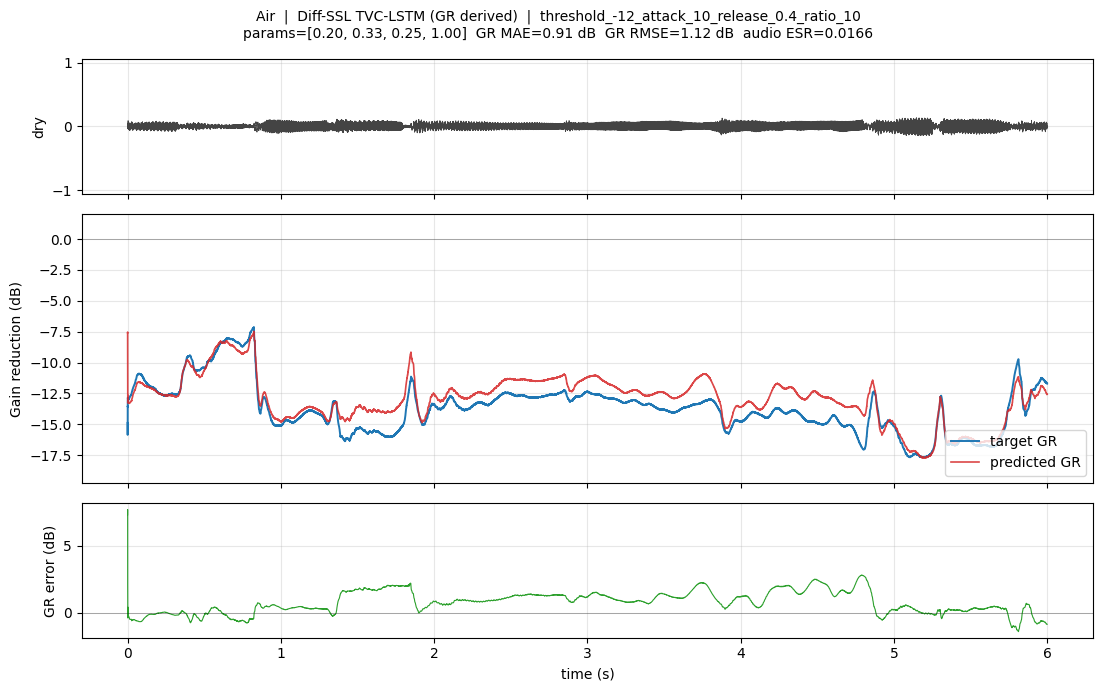

In [8]:
# Single prediction preview — held-out test song x lowest-threshold setting
song, setting = TEST_PAIR_KEYS[0]
_ = visualize_prediction(setting=setting, song=song, start_sec=30.0, duration_sec=6.0)


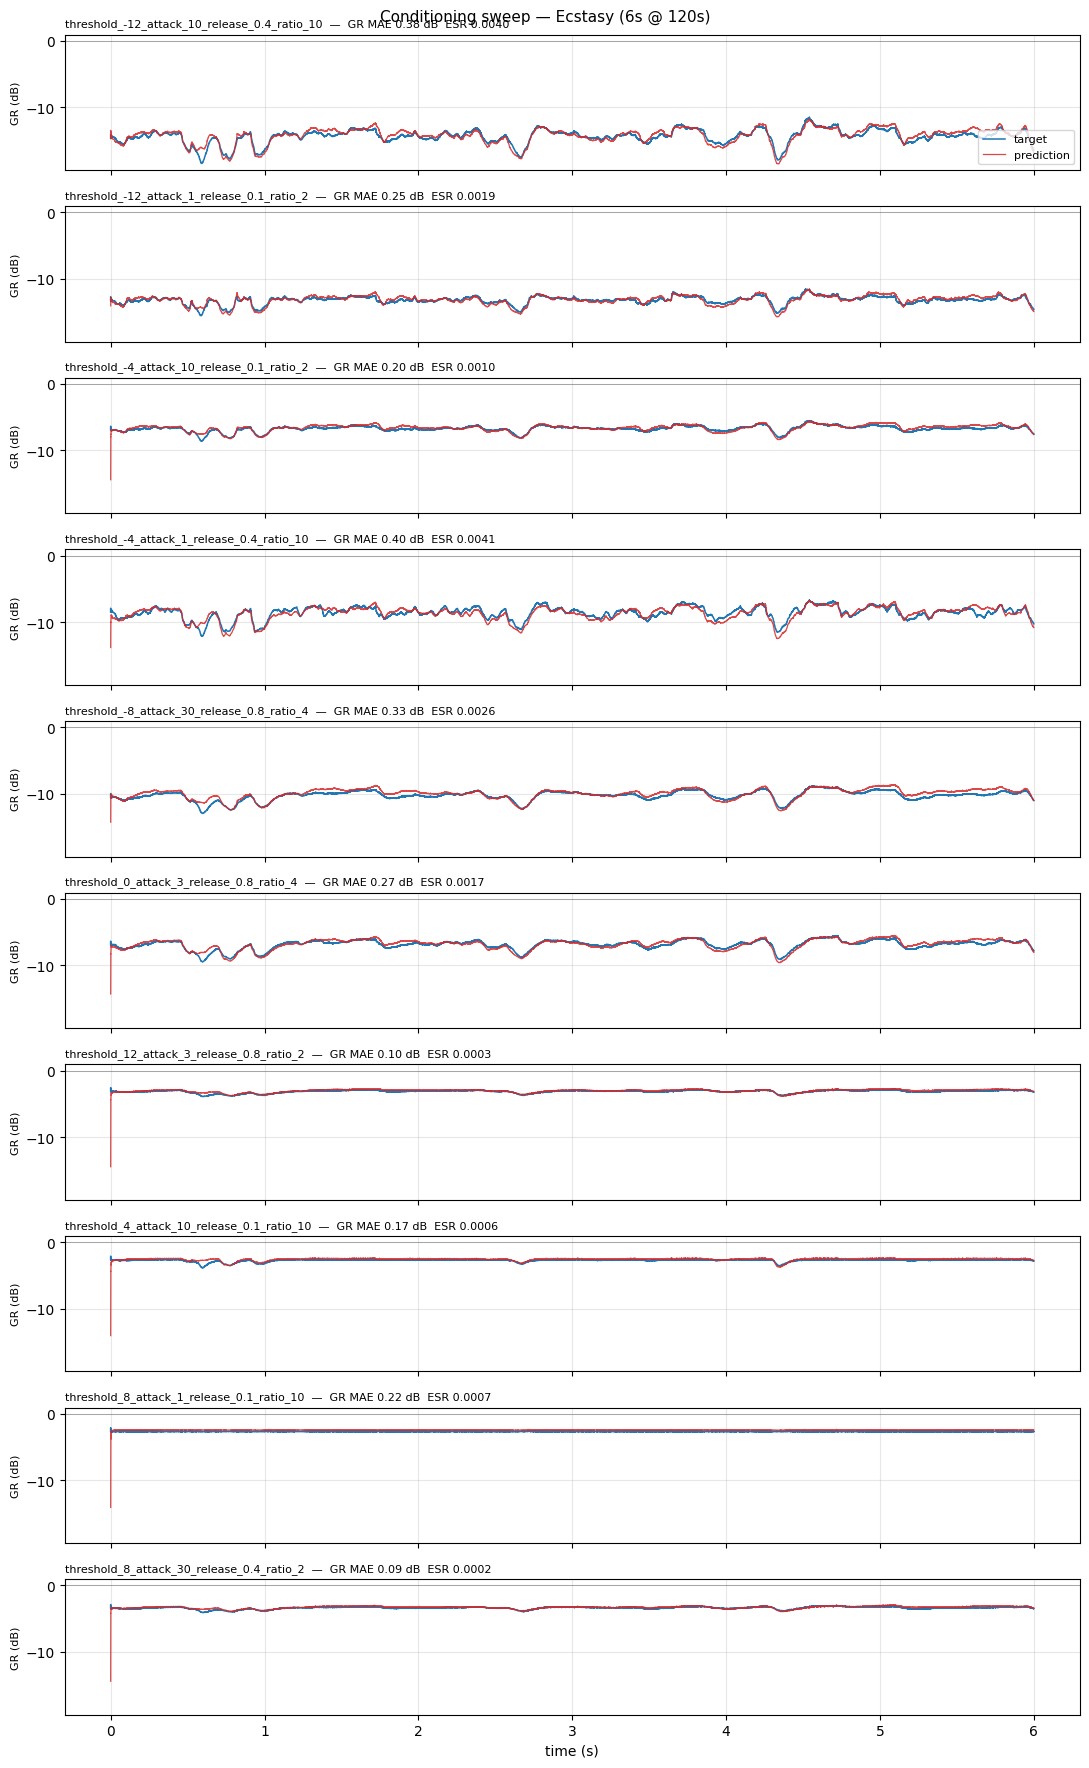

,setting,GR MAE (dB),GR RMSE (dB),ESR
0,threshold_-12_attack_10_release_0.4_ratio_10,0.376575,0.470625,0.003989
1,threshold_-12_attack_1_release_0.1_ratio_2,0.248393,0.302499,0.001900
2,threshold_-4_attack_10_release_0.1_ratio_2,0.203770,0.259312,0.000951
3,threshold_-4_attack_1_release_0.4_ratio_10,0.396105,0.497476,0.004123
4,threshold_-8_attack_30_release_0.8_ratio_4,0.334402,0.433323,0.002578
5,threshold_0_attack_3_release_0.8_ratio_4,0.268672,0.335915,0.001711
6,threshold_12_attack_3_release_0.8_ratio_2,0.103473,0.135986,0.000269
7,threshold_4_attack_10_release_0.1_ratio_10,0.171131,0.199580,0.000589
8,threshold_8_attack_1_release_0.1_ratio_10,0.222127,0.227503,0.000738
9,threshold_8_attack_30_release_0.4_ratio_2,0.092906,0.124502,0.000228


In [9]:
# Conditioning sweep: validation song through all 10 settings
sweep_curves, sweep_df = conditioning_sweep(start_sec=120.0, duration_sec=6.0)


In [10]:
# ── 7. Eval helpers: score a list of pairs, summarise, per-setting ──
#
# Shared by the validation and test split cells below. Each pair's whole
# song is predicted state-continuously, then split into fixed windows scored
# with src.losses.compute_all_losses; results are duration-weighted.

from src.dsp import parse_settings_from_folder_name

WHOLE_SONG_CHUNK_SEC = 10.0
SAVE_CHUNK_METRICS = False
MODEL_NAME = "diffssl_lstm_tvc"

metric_cols = ["MAE (L1)", "MSE (L2)", "ESR", "MR-STFT", "EDC", "M_NRMSE", "M_SF"]

system, hp = EVAL_SYSTEM, HP
sr = int(hp["sample_rate"]); device = torch.device(DEVICE)
block = _cond_block_size(hp)


def score_pairs(pairs, *, chunk_sec=WHOLE_SONG_CHUNK_SEC):
    """Predict every pair state-continuously and return per-window metric rows."""
    metric_frames = int(round(chunk_sec * sr))
    chunk_rows = []
    for idx, pair in enumerate(pairs, start=1):
        song, setting = pair["song"], pair["setting"]
        dry, wet, pred = predict_wet_song(system, pair, sr, device,
                                          block_size=block, chunk_sec=chunk_sec)
        total = pred.shape[-1]
        print(f"[{idx}/{len(pairs)}] {song} | {setting} ({total/sr:.1f}s)")
        for chunk_idx, start in enumerate(range(0, total, metric_frames), start=1):
            stop = min(start + metric_frames, total)
            p_chunk = pred[..., start:stop]; w_chunk = wet[..., start:stop]
            if p_chunk.shape[-1] <= 0:
                continue
            losses = compute_all_losses(p_chunk.unsqueeze(0), w_chunk.unsqueeze(0))
            chunk_rows.append({"Song": song, "Setting": setting, "Chunk": chunk_idx,
                               "Start (s)": start / sr, "Duration (s)": p_chunk.shape[-1] / sr,
                               "Frames": p_chunk.shape[-1], **losses})
        del dry, wet, pred
        if device.type == "cuda":
            torch.cuda.empty_cache()
        gc.collect()
    return chunk_rows


def summarize_split(chunk_rows, pairs, split_name):
    weighted = _weighted_average_metric_rows(chunk_rows, metric_cols)
    total_frames = sum(r["Frames"] for r in chunk_rows)
    return pd.DataFrame([{
        "Split": split_name, "Model": MODEL_NAME, "Run": RUN_NAME,
        "Songs": len(sorted(set(p["song"] for p in pairs))),
        "Settings": len(sorted(set(p["setting"] for p in pairs))),
        "Chunks": len(chunk_rows), "Duration (s)": total_frames / sr, **weighted,
    }])


def per_setting_table(chunk_rows):
    rows = []
    for setting in sorted(set(r["Setting"] for r in chunk_rows)):
        rs = [r for r in chunk_rows if r["Setting"] == setting]
        w = _weighted_average_metric_rows(rs, metric_cols)
        parsed = parse_settings_from_folder_name(setting)
        rows.append({
            "Setting": setting,
            "threshold": float(parsed["threshold"]), "ratio": float(parsed["ratio"]),
            "attack": float(parsed["attack"]), "release": float(parsed["release"]),
            "Chunks": len(rs), "Duration (s)": sum(r["Frames"] for r in rs) / sr, **w,
        })
    return pd.DataFrame(rows).sort_values("threshold").reset_index(drop=True)


def run_split(pairs, split_name):
    """Score `pairs`, save the summary + per-setting CSVs, return both frames."""
    assert pairs, f"No {split_name} pairs selected."
    print(f"{split_name.capitalize()} pairs: {len(pairs)} "
          f"({len(sorted(set(p['song'] for p in pairs)))} songs × "
          f"{len(sorted(set(p['setting'] for p in pairs)))} settings)")
    chunk_rows = score_pairs(pairs)
    assert chunk_rows, f"No {split_name} chunks evaluated."

    summary = summarize_split(chunk_rows, pairs, split_name)
    per_setting = per_setting_table(chunk_rows)

    summary.to_csv(Path(RUN_DIR) / f"eval_audio_metrics_{split_name}.csv", index=False)
    per_setting.to_csv(Path(RUN_DIR) / f"eval_audio_metrics_{split_name}_per_setting.csv", index=False)
    if SAVE_CHUNK_METRICS:
        pd.DataFrame(chunk_rows).to_csv(
            Path(RUN_DIR) / f"eval_audio_metrics_{split_name}_chunks.csv", index=False)
    print(f"Saved {split_name} metrics -> eval_audio_metrics_{split_name}[_per_setting].csv")
    return chunk_rows, summary, per_setting


print("Split-eval helpers registered.")

Split-eval helpers registered.


Validation pairs: 10 (1 songs × 10 settings)
[1/10] Ecstasy | threshold_-12_attack_10_release_0.4_ratio_10 (257.7s)
[2/10] Ecstasy | threshold_-12_attack_1_release_0.1_ratio_2 (257.7s)
[3/10] Ecstasy | threshold_-4_attack_10_release_0.1_ratio_2 (257.7s)
[4/10] Ecstasy | threshold_-4_attack_1_release_0.4_ratio_10 (257.7s)
[5/10] Ecstasy | threshold_-8_attack_30_release_0.8_ratio_4 (257.7s)
[6/10] Ecstasy | threshold_0_attack_3_release_0.8_ratio_4 (257.7s)
[7/10] Ecstasy | threshold_12_attack_3_release_0.8_ratio_2 (257.7s)
[8/10] Ecstasy | threshold_4_attack_10_release_0.1_ratio_10 (257.7s)
[9/10] Ecstasy | threshold_8_attack_1_release_0.1_ratio_10 (257.7s)
[10/10] Ecstasy | threshold_8_attack_30_release_0.4_ratio_2 (257.7s)
Saved validation metrics -> eval_audio_metrics_validation[_per_setting].csv


,Split,Model,Run,Songs,Settings,Chunks,Duration (s),MAE (L1),MSE (L2),ESR,MR-STFT,EDC,M_NRMSE,M_SF
0,validation,diffssl_lstm_tvc,diffssl_tvc_20260624_153343_diffssl_lstm32_tvc...,1,10,260,2577.464626,0.000442,4.685652e-07,0.22544,0.053666,0.325229,0.094641,0.050303


,Setting,threshold,ratio,attack,release,Chunks,Duration (s),MAE (L1),MSE (L2),ESR,MR-STFT,EDC,M_NRMSE,M_SF
0,threshold_-12_attack_10_release_0.4_ratio_10,-12.0,10.0,10.0,0.4,26,257.746463,0.000413,3.351289e-07,0.886534,0.106223,0.416111,0.209252,0.094869
1,threshold_-12_attack_1_release_0.1_ratio_2,-12.0,2.0,1.0,0.1,26,257.746463,0.000291,1.736460e-07,0.250042,0.065417,0.351445,0.111962,0.072225
2,threshold_-8_attack_30_release_0.8_ratio_4,-8.0,4.0,30.0,0.8,26,257.746463,0.000418,3.872299e-07,0.032373,0.054017,0.300492,0.065668,0.060240
3,threshold_-4_attack_10_release_0.1_ratio_2,-4.0,2.0,10.0,0.1,26,257.746463,0.000367,3.091356e-07,0.081403,0.040439,0.309532,0.064732,0.039961
4,threshold_-4_attack_1_release_0.4_ratio_10,-4.0,10.0,1.0,0.4,26,257.746463,0.000771,1.399198e-06,0.270283,0.086599,0.397522,0.144485,0.092593
5,threshold_0_attack_3_release_0.8_ratio_4,0.0,4.0,3.0,0.8,26,257.746463,0.000554,6.941322e-07,0.042930,0.046403,0.309240,0.065196,0.050894
6,threshold_4_attack_10_release_0.1_ratio_10,4.0,10.0,10.0,0.1,26,257.746463,0.000478,4.371863e-07,0.089846,0.033180,0.281117,0.059325,0.026498
7,threshold_8_attack_1_release_0.1_ratio_10,8.0,10.0,1.0,0.1,26,257.746463,0.000622,6.502142e-07,0.388220,0.053537,0.304496,0.117463,0.030565
8,threshold_8_attack_30_release_0.4_ratio_2,8.0,2.0,30.0,0.4,26,257.746463,0.000241,1.292950e-07,0.110047,0.025226,0.290975,0.054371,0.017072
9,threshold_12_attack_3_release_0.8_ratio_2,12.0,2.0,3.0,0.8,26,257.746463,0.000268,1.704867e-07,0.102726,0.025616,0.291355,0.053957,0.018113


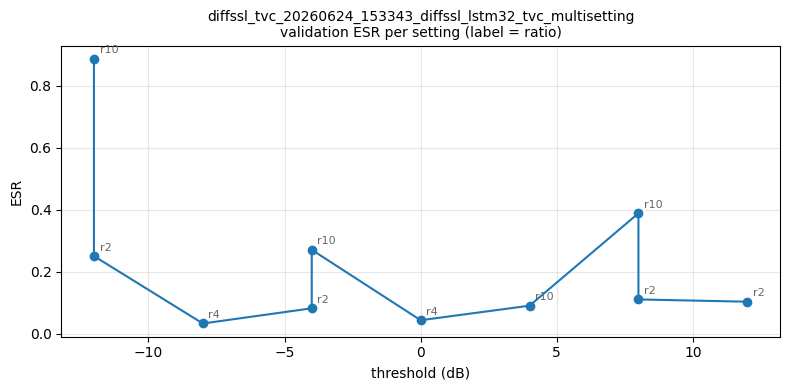

In [11]:
# ── 8. Validation split (val song × all 10 settings) ────────────
#
# The exact per-run split manifest. Saved as eval_audio_metrics_validation.csv
# (same schema as the SOTA / GR runs) plus a per-setting breakdown so
# conditioning quality is visible across the threshold sweep.

MAX_VALIDATION_PAIRS: int | None = None      # int for a quick smoke test
EVAL_SETTINGS: list[str] | None = None       # restrict to these settings

val_pairs = validation_pairs(SPLIT_PATH)
if EVAL_SETTINGS is not None:
    val_pairs = [p for p in val_pairs if p["setting"] in set(EVAL_SETTINGS)]
if MAX_VALIDATION_PAIRS is not None:
    val_pairs = val_pairs[:MAX_VALIDATION_PAIRS]

val_chunk_rows, validation_metrics_df, val_per_setting_df = run_split(val_pairs, "validation")
display(validation_metrics_df)
display(val_per_setting_df)

# ESR vs threshold — quick visual of where conditioning struggles.
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(val_per_setting_df["threshold"], val_per_setting_df["ESR"], "o-", color="#1f77b4")
for _, r in val_per_setting_df.iterrows():
    ax.annotate(f"r{r['ratio']:.0f}", (r["threshold"], r["ESR"]),
                textcoords="offset points", xytext=(4, 4), fontsize=8, color="#666")
ax.set_xlabel("threshold (dB)"); ax.set_ylabel("ESR"); ax.grid(alpha=0.3)
ax.set_title(f"{RUN_NAME}\nvalidation ESR per setting (label = ratio)", fontsize=10)
plt.tight_layout(); plt.show()

In [12]:
# ── 9. Test split (held-out songs × lowest-threshold settings) ──────
#
# The unseen generalisation set from the split manifest: test_songs that the
# model never saw, evaluated on the lowest-threshold (heaviest-compression)
# settings. Saved as eval_audio_metrics_test.csv with the same schema.

MAX_TEST_PAIRS: int | None = None

tst_pairs = test_pairs(SPLIT_PATH)
if MAX_TEST_PAIRS is not None:
    tst_pairs = tst_pairs[:MAX_TEST_PAIRS]

test_chunk_rows, test_metrics_df, test_per_setting_df = run_split(tst_pairs, "test")
display(test_metrics_df)
display(test_per_setting_df)

Test pairs: 4 (2 songs × 2 settings)
[1/4] Air | threshold_-12_attack_10_release_0.4_ratio_10 (195.5s)
[2/4] AncoraQui | threshold_-12_attack_10_release_0.4_ratio_10 (233.5s)
[3/4] Air | threshold_-12_attack_1_release_0.1_ratio_2 (195.5s)
[4/4] AncoraQui | threshold_-12_attack_1_release_0.1_ratio_2 (233.5s)
Saved test metrics -> eval_audio_metrics_test[_per_setting].csv


,Split,Model,Run,Songs,Settings,Chunks,Duration (s),MAE (L1),MSE (L2),ESR,MR-STFT,EDC,M_NRMSE,M_SF
0,test,diffssl_lstm_tvc,diffssl_tvc_20260624_153343_diffssl_lstm32_tvc...,2,2,88,857.86059,0.000467,4.512031e-07,0.114772,0.082934,0.440807,0.098846,0.12893


,Setting,threshold,ratio,attack,release,Chunks,Duration (s),MAE (L1),MSE (L2),ESR,MR-STFT,EDC,M_NRMSE,M_SF
0,threshold_-12_attack_10_release_0.4_ratio_10,-12.0,10.0,10.0,0.4,44,428.930295,0.000556,6.230388e-07,0.178130,0.101587,0.504511,0.125458,0.148936
1,threshold_-12_attack_1_release_0.1_ratio_2,-12.0,2.0,1.0,0.1,44,428.930295,0.000377,2.793674e-07,0.051415,0.064282,0.377103,0.072234,0.108924


## Side-by-side comparison across Diff-SSL TVC runs

Each run folder under `diffssl_tvc_runs/` writes
`eval_audio_metrics_validation.csv` and `eval_audio_metrics_test.csv` with the
same metric columns. The cell below collects both splits from every run so
checkpoints / configs (e.g. `LSTM32TVC` vs `LSTM96TVC`) can be compared
one-to-one on the identical splits.

In [13]:
# ── 10. Collect all Diff-SSL TVC eval CSVs (val + test) into one table ──

rows = []
for split_name in ("validation", "test"):
    for csv_path in sorted(glob.glob(os.path.join(RUNS_DIR, "*", f"eval_audio_metrics_{split_name}.csv"))):
        try:
            df = pd.read_csv(csv_path)
        except Exception:
            continue
        run_name = Path(csv_path).parent.name
        if "Run" not in df.columns:
            df.insert(0, "Run", run_name)
        # annotate with hidden size / epochs from hparams when available
        hp_path = Path(csv_path).parent / "hparams.json"
        if hp_path.is_file():
            try:
                _hp = json.loads(hp_path.read_text())
                df["hidden"] = _hp.get("model", {}).get("hidden_size")
                df["max_epochs"] = _hp.get("max_epochs")
            except Exception:
                pass
        rows.append(df)

if rows:
    comparison = pd.concat(rows, ignore_index=True)
    front = [c for c in ["Run", "Model", "Split", "hidden", "max_epochs",
                         "Songs", "Settings", "Chunks", "Duration (s)"] if c in comparison.columns]
    comparison = comparison[front + [c for c in comparison.columns if c not in front]]
    if {"Run", "Split"}.issubset(comparison.columns):
        comparison = comparison.sort_values(["Run", "Split"]).reset_index(drop=True)
    display(comparison)
    out = os.path.join(RUNS_DIR, "comparison_diffssl_tvc.csv")
    comparison.to_csv(out, index=False)
    print(f"Saved -> {out}")
else:
    print("No eval CSVs found yet. Run the validation/test cells above first (per run).")

,Run,Model,Split,hidden,max_epochs,Songs,Settings,Chunks,Duration (s),MAE (L1),MSE (L2),ESR,MR-STFT,EDC,M_NRMSE,M_SF
0,diffssl_tvc_20260624_153343_diffssl_lstm32_tvc...,diffssl_lstm_tvc,test,32,100,2,2,88,857.860590,0.000467,4.512031e-07,0.114772,0.082934,0.440807,0.098846,0.128930
1,diffssl_tvc_20260624_153343_diffssl_lstm32_tvc...,diffssl_lstm_tvc,validation,32,100,1,10,260,2577.464626,0.000442,4.685652e-07,0.225440,0.053666,0.325229,0.094641,0.050303


Saved -> /Volumes/Saola's Drive/AllCode/thesis/data/diffssl_tvc_runs/comparison_diffssl_tvc.csv
